In [2]:
import pandas as pd

In [3]:
# считываю данные без внутренней индексации pandas, так как для этого уже есть столбец
train_data = pd.read_excel('Training.xlsx', index_col='ID')
test_data = pd.read_excel('Test.xlsx', index_col='ID')

In [41]:
# определение задачи + отделение таргета от датасета
x_train, y_train = train_data.drop(columns=['MARKER']), train_data['MARKER']
x_test, y_test = test_data.drop(columns=['MARKER']), test_data['MARKER']
print(f'Тип данных целевой переменной: {y_train.dtype}\nМножество возможных значений: {y_train.unique()}')

Тип данных целевой переменной: int64
Множество возможных значений: [0 1]


Целевой переменной является признак MARKER, принимающий значения 0 и 1. Следовательно, задача представляет собой задачу бинарной классификации.

In [42]:
# EDA
x_train.head()

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
ID,,,,,,,,,,,,,,,,,,,,,
1,0.198778,0.099389,0.00,799.90,1.777556,0.888778,13,3.49,woman,33.750000,...,property,No,Works,Yes,Yes,No,Yes,No,3.393876,2.432165
2,0.043000,0.021264,49.97,173.03,NaN,0.190143,13,3.49,Woman,33.250000,...,otherwise,No,Works,Yes,Yes,Yes,Yes,No,-0.517659,1.209422
3,0.067073,0.067073,0.00,329.90,0.599818,0.599818,13,3.49,Woman,38.583333,...,property,No,No couple,No,Yes,No,Yes,No,4.645817,1.821789
4,0.052700,0.052700,0.00,235.65,0.471300,0.471300,13,3.49,Woman,61.250000,...,property,No,No couple,Yes,Yes,Few,Yes,No,-3.055776,1.602076
5,0.141880,0.141880,0.00,634.45,1.268900,1.268900,13,3.49,Woman,48.583333,...,property,No,No couple,Yes,No,No,No,No,-3.474083,3.556995


In [43]:
print(f'Размерность тренировочного датасета: {x_train.shape}')
print(f'Размерность тестирующего датасета: {x_test.shape}')

Размерность тренировочного датасета: (91528, 26)
Размерность тестирующего датасета: (38405, 26)


Обучающая выборка содержит 91 528 наблюдений, тестовая - 38 405 наблюдений. Размер выборки достаточен для применения как линейных моделей, так и ансамблевых методов.

In [44]:
# распределение целевой переменной
y_train.value_counts(normalize=True)

MARKER
0    0.996209
1    0.003791
Name: proportion, dtype: float64

Наблюдается очень сильный дисбаланс классов. Доля клиентов с дефолтом составляет около 0.38%, тогда как доля клиентов без дефолта превышает 99%.

В связи с этим полагаться на метрику Accuracy нецелесообразно, поскольку можно взять модель, предсказывающую всегда отсутствие дефолта для всех клиентов, и она будет демонстрировать очень высокую точность при отсутствии какой-либо реальной пользы.
При построении моделей особое внимание следует уделить метрикам, учитывающим дисбаланс классов.

In [45]:
all_types = train_data.dtypes.unique().astype(str).tolist()
categorical_features = x_train.select_dtypes(include='object').columns.to_list()
numeric_features = x_train.select_dtypes(include=['float64', 'int64']).columns.to_list()
all_features = categorical_features + numeric_features
print(f'Все типы данных в датасете: {all_types}')
print(f'Все категориальные признаки({len(categorical_features)}/{x_train.shape[1]}): {categorical_features}')

Все типы данных в датасете: ['float64', 'int64', 'object']
Все категориальные признаки(14/26): ['I', 'K', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X']


В датасете всего три возможных типа данных у признаков: `float64`, `int64`, `object`. Также, как мы можем увидеть в выводе, в датасете большая часть признаков - категориальные. Это очень важно для дальнейшей работы и выбора моделей.
Что еще бросается в глаза, это то что в некоторых признаках одно и то же слово может быть написано в разных регистрах, хотя суть одна и та же. Надо изучить этот момент

In [46]:
# изучаем число уникальных значений признаков с привидением к одному регистру и без приведения
all_features = categorical_features + numeric_features
cat_unique = pd.DataFrame({'Признак': categorical_features, 'Уникальных значений(без приведения)': [x_train[col].nunique() for col in categorical_features],
                           'Уникальных значений(с приведением)': [x_train[col].str.lower().nunique() for col in categorical_features]})
display(cat_unique.style.hide())

Признак,Уникальных значений(без приведения),Уникальных значений(с приведением)
I,10,6
K,7,7
M,5,5
N,4,4
O,4,4
P,5,5
Q,3,3
R,2,2
S,5,5
T,2,2


Как видно в выводе, в признаке `I` стало меньше уникальных значений после приведения. Но в будущем нам надо будет привести ВСЕ категориальные признаки к одному регистру (например, нижнему), так как мы не можем гарантировать что на инференсе нам не смешают регистры для других признаков

In [47]:
# исследование данных на пропуски
from IPython.display import display_html

cat_null = pd.DataFrame({'Категориальный признак': categorical_features, 'Пропуски (%)': [x_train[col].isna().sum() / len(x_train) * 100 for col in categorical_features]})
num_null = pd.DataFrame({'Числовой признак': numeric_features, 'Пропуски (%)': [x_train[col].isna().sum() / len(x_train) * 100 for col in numeric_features]})

style_cat = cat_null.style.hide().set_table_attributes("style='display:inline; margin-right:40px;'").to_html()
style_num = num_null.style.hide().set_table_attributes("style='display:inline;'").to_html()

display_html(style_cat + style_num, raw=True)

Категориальный признак,Пропуски (%)
I,0.000000
K,4.185604
M,0.000000
N,0.000000
O,0.000000
P,0.000000
Q,0.000000
R,0.000000
S,4.014072
T,0.000000


In [48]:
nan_impact_cat = {}
for col in categorical_features:
    stats = train_data.groupby(train_data[col].isna())['MARKER'].mean()
    nan_impact_cat[col] = {
        'Данные есть (False)': stats.get(False, 0),
        'Пропуск (True)': stats.get(True, 0)
    }
df_nan_impact = pd.DataFrame(nan_impact_cat).T
display(df_nan_impact.style.format('{:.4%}'))

,Данные есть (False),Пропуск (True)
I,0.3791%,0.0000%
K,0.3752%,0.4699%
M,0.3791%,0.0000%
N,0.3791%,0.0000%
O,0.3791%,0.0000%
P,0.3791%,0.0000%
Q,0.3791%,0.0000%
R,0.3791%,0.0000%
S,0.3825%,0.2994%
T,0.3791%,0.0000%


Большинство признаков в датасете полностью заполнены, однако в ряде колонок присутствуют пропуски различной степени выраженности.

### Категориальные признаки

Пропуски обнаружены в признаках `K`, `S`, `U` и `W`. Их доля варьируется от 0.5% до 6.9%, тогда как остальные категориальные признаки заполнены полностью.

Дополнительно была исследована связь факта пропуска с целевой переменной. Для признаков `U` и `W` доля дефолтов среди объектов с пропусками заметно выше, чем среди объектов без пропусков. Особенно выделяется признак `U`, где частота дефолта при наличии пропуска составляет 0.66% против 0.38% при наличии значения.
Это позволяет предположить, что сам факт отсутствия значения может содержать полезную информацию для модели.

### Числовые признаки

Пропуски присутствуют в признаках `A`, `E`, `H`, `L` и `Z`.

Наибольший интерес представляет признак `Z`, в котором отсутствует 50% значений. Также заметная доля пропусков наблюдается в признаках `H` (≈15%) и `L` (≈9%).

Анализ связи пропусков с целевой переменной показал, что для признаков `E` и `Z` доля дефолтов среди объектов с пропущенными значениями выше среднего уровня по выборке. В то же время для признака `L` наблюдается обратный эффект: объекты с пропусками имеют более низкую долю дефолтов.
Таким образом, механизм возникновения пропусков, вероятно, не является полностью случайным.
### Выводы
Пропуски присутствуют как среди числовых, так и среди категориальных признаков и в ряде случаев связаны с вероятностью дефолта.
По этой причине при построении моделей целесообразно не только выполнять заполнение пропущенных значений, но и рассмотреть создание дополнительных бинарных индикаторов пропуска для признаков, где различия наиболее заметны (`U`, `W`, `E`, `L`, `Z`).
Окончательное решение о способе обработки пропусков будет принято после оценки качества моделей на валидационной выборке.

In [49]:
tmp = train_data.copy()
html_string = ''
for col in categorical_features:
    tmp[col] = tmp[col].str.lower().str.strip()
    grouped = tmp.groupby(col)['MARKER'].agg(['count', 'mean']).sort_values('mean', ascending=False)
    styled_table = grouped.style.format({'mean': '{:.4%}'}).set_caption(f"Признак: <b>{col}</b>")\
                                .set_table_attributes("style='display:inline-table; margin-right:25px; min-width:180px; vertical-align:top;'")\
                                .to_html()
    html_string += styled_table
full_html = f"<div style='overflow-x:auto; white-space:nowrap; padding-bottom:15px;'>{html_string}</div>"
display_html(full_html, raw=True)

,count,mean
I,,
man,41554,0.4452%
woman,49974,0.3242%
,count,mean
K,,
gomel region,12232,0.4415%
mogilev region,8688,0.4259%
vitebsk region,12285,0.4233%
brest region,13603,0.4117%
minsk region,14937,0.3883%


### Анализ категориальных признаков

Для оценки информативности категориальных признаков была рассчитана доля дефолтов внутри каждой категории. Перед анализом значения были приведены к нижнему регистру и очищены от лишних пробелов.

Наиболее заметные различия между категориями наблюдаются для признаков `N`, `O`, `Q`, `R`, `S`, `W` и `X`, что указывает на их потенциально высокую предсказательную способность.

Например:

- для признака `N` частота дефолтов снижается по мере роста уровня образования;
- для признака `O` наименьшая доля дефолтов наблюдается среди категории `married`;
- для признака `Q` категория `rent/hire` имеет более высокий уровень дефолтов по сравнению с `property`;
- для признаков `R`, `W` и `X` наблюдаются существенные различия между значениями `yes` и `no`.

Следует учитывать, что отдельные категории содержат небольшое количество наблюдений, поэтому выводы надо делать с осторожностью.

In [50]:
# теперь изучим глубже числовые признаки
x_train[numeric_features].describe()

,A,B,C,D,E,F,G,H,J,L,Y,Z
count,86943.000000,91528.000000,91528.000000,91528.00000,88800.000000,91528.000000,91528.000000,77807.000000,91528.000000,83281.000000,91528.000000,45764.000000
mean,0.169420,0.113475,85.733249,548.22986,1.011086,0.683460,7.854788,0.506687,41.141414,103.703822,-0.010495,4.326198
std,0.167930,0.105300,105.208403,448.57005,0.910680,0.622050,4.754852,0.925653,11.127760,100.528540,2.885108,161.137396
min,0.000002,0.000001,0.000000,49.98000,0.000016,0.000012,2.000000,0.000000,21.000000,0.000000,-4.999972,1.000012
25%,0.065585,0.042912,20.520000,227.03000,0.405825,0.263742,4.000000,0.000000,32.083333,29.000000,-2.510580,1.303152
50%,0.119160,0.079730,50.030000,408.21000,0.749062,0.499178,5.000000,0.000000,40.000000,69.000000,-0.016137,1.654461
75%,0.221319,0.146909,108.800000,745.73000,1.332953,0.898975,13.000000,0.010000,50.000000,144.000000,2.494074,2.473961
max,7.067250,0.874025,2682.420000,4999.00000,35.337000,10.352991,24.000000,3.500000,64.916667,540.000000,4.999754,31350.724328


### Анализ числовых признаков

Для числовых признаков были рассчитаны основные описательные статистики.

Большинство признаков имеют широкий диапазон значений и выраженную асимметрию распределений. Особенно заметно это для признаков `A`, `C`, `D`, `E`, `F`, `L` и `Z`, где максимальные значения значительно превышают верхние квартили, что может свидетельствовать о наличии выбросов или длинных правых хвостов распределений.

Отдельного внимания заслуживает признак `Z`, содержащий 50% пропусков и крайне большие максимальные значения по сравнению с медианой. Это указывает на наличие редких экстремальных наблюдений и требует дополнительного исследования.

Также признаки `G` и `H` обладают нетипичными распределениями. Для признака `G` наблюдается ограниченное число целочисленных значений, а для признака `H` большая часть наблюдений сосредоточена около нуля. Данные признаки будут дополнительно исследованы на следующих этапах анализа.

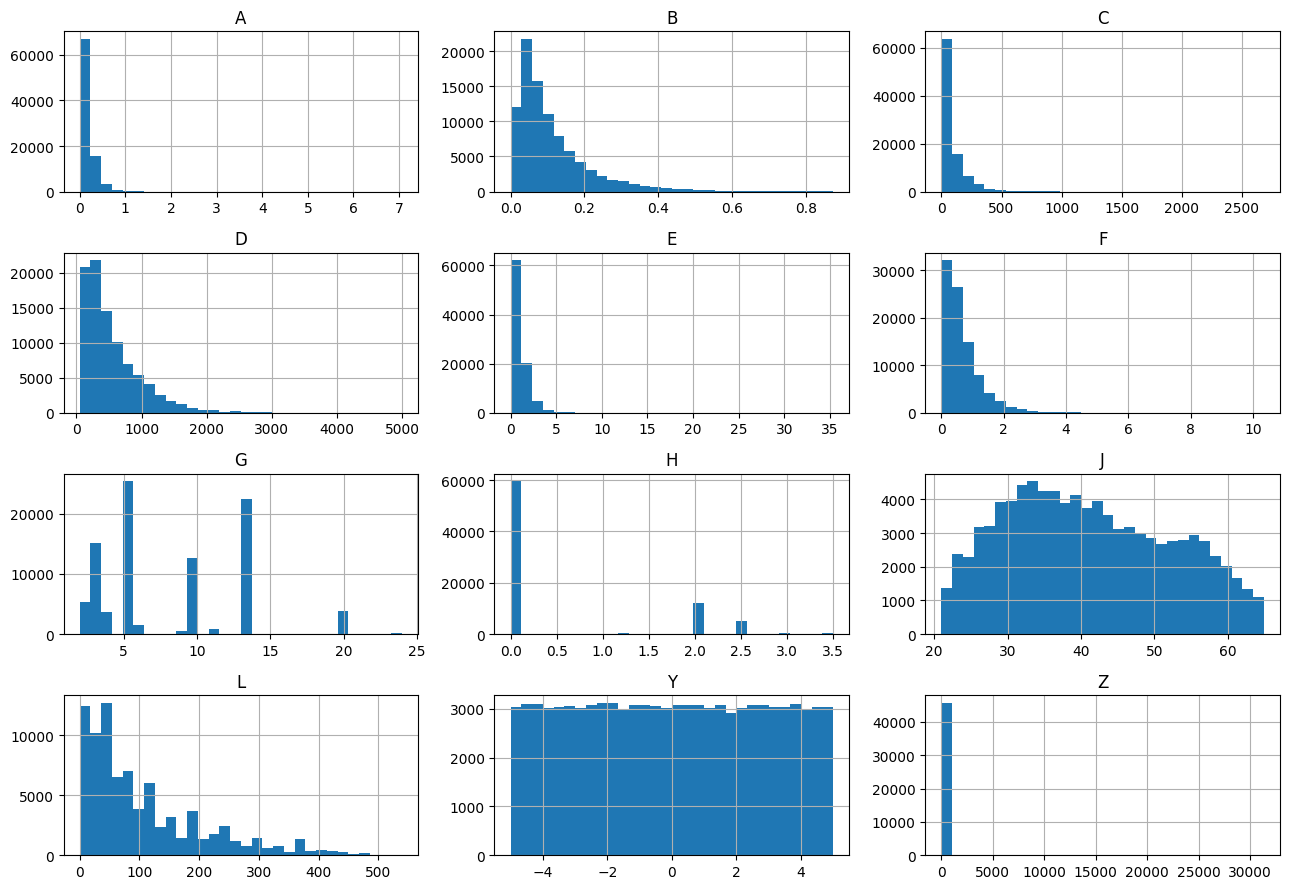

In [51]:
# респределение числовых признаков
import matplotlib.pyplot as plt
x_train[numeric_features].hist(figsize=(13,9), bins=30)
plt.tight_layout()
plt.show()

### Анализ распределений числовых признаков

Для числовых признаков были построены гистограммы распределений.

Большинство признаков (`A`, `B`, `C`, `D`, `E`, `F`, `L`, `Z`) имеют выраженную правостороннюю асимметрию: основная масса наблюдений сосредоточена в области небольших значений, при этом присутствуют отдельные крупные значения, формирующие длинный правый хвост распределения. Данный результат согласуется с ранее полученными описательными статистиками.

Признаки `G` и `H` имеют более специфический характер распределения. Для признака `G` наблюдается ограниченное число дискретных значений, а для признака `H` значительная часть наблюдений сосредоточена около нуля.

Признак `J` обладает наиболее близким к симметричному распределением среди всех числовых признаков, тогда как признак `Y` демонстрирует распределение, близкое к равномерному на всем диапазоне значений.

Построенные гистограммы подтверждают наличие асимметрии и потенциальных выбросов в ряде числовых признаков. Эти особенности необходимо учитывать на этапе предобработки данных и построения моделей.


In [52]:
quaters = train_data.groupby('MARKER')[numeric_features].quantile([0.25, 0.50, 0.75])
display(quaters.T)

MARKER           0                                   1              \
              0.25        0.50        0.75        0.25        0.50   
A         0.065473    0.119067    0.221414    0.087014    0.136383   
B         0.042871    0.079595    0.146810    0.066756    0.106922   
C        20.700000   50.020000  108.530000    0.000000   60.010000   
D       227.030000  407.560000  743.850000  426.555000  699.270000   
E         0.404950    0.748500    1.331260    0.818474    1.252469   
F         0.262829    0.498214    0.897324    0.601678    0.988355   
G         4.000000    5.000000   13.000000   10.500000   13.000000   
H         0.000000    0.000000    0.010000    0.000000    1.990000   
J        32.083333   40.083333   50.000000   29.041667   35.666667   
L        29.000000   70.000000  144.000000   12.000000   36.000000   
Y        -2.511418   -0.016829    2.491672   -2.373886    0.443564   
Z         1.302258    1.652022    2.466961    1.771598    2.718245   

MARKER               
               0.75  
A          0.209259  
B          0.158258  
C        128.940000  
D       1109.450000  
E          1.787999  
F          1.445019  
G         13.000000  
H          2.490000  
J         43.000000  
L         62.000000  
Y          2.831307  
Z          4.187131

### Связь числовых признаков с целевой переменной

Для оценки информативности числовых признаков были сопоставлены квартильные характеристики (25%, 50%, 75%) для клиентов с дефолтом и без дефолта.

Наиболее выраженные различия наблюдаются для признаков `G`, `H`, `L` и `Z`. Например, для дефолтных клиентов значения признака `G` существенно выше практически на всех квартилях, а признак `H` демонстрирует резкий сдвиг распределения относительно клиентов без дефолта. В свою очередь, признак `L` показывает обратную зависимость: значения для дефолтных клиентов заметно ниже по всему распределению.

Также заметимые различия между группами наблюдаются для признаков `C`, `D`, `E` и `F`, что может свидетельствовать о наличии связи данных признаков с вероятностью дефолта.

Для признаков `A`, `B` и `Y` различия присутствуют, однако выражены значительно слабее.

Полученные результаты позволяют предположить, что ряд числовых признаков обладает хорошей разделяющей способностью и может внести существенный вклад в качество итоговой модели.


In [53]:
# выявление связи пропусков с таргетом в числовых признаках
nan_impact_num = {}
for col in numeric_features:
    stats = train_data.groupby(train_data[col].isna())['MARKER'].mean()
    nan_impact_num[col] = {
        'Данные есть (False)': stats.get(False, 0),
        'Пропуск (True)': stats.get(True, 0)
    }
df_nan_impact = pd.DataFrame(nan_impact_num).T
display(df_nan_impact.style.format('{:.4%}'))

,Данные есть (False),Пропуск (True)
A,0.3784%,0.3926%
B,0.3791%,0.0000%
C,0.3791%,0.0000%
D,0.3791%,0.0000%
E,0.3773%,0.4399%
F,0.3791%,0.0000%
G,0.3791%,0.0000%
H,0.3843%,0.3498%
J,0.3791%,0.0000%
L,0.3938%,0.2304%


### Анализ пропусков относительно целевой переменной

Для признаков с пропущенными значениями была дополнительно исследована доля дефолтов среди объектов с заполненными и отсутствующими значениями.

Для большинства признаков различия между группами остаются умеренными, однако для отдельных переменных наблюдаются заметные отклонения от среднего уровня дефолтности.
Наиболее выраженные различия выявлены для признаков `U`, `W`, `E`, `L` и `Z`. Например, для признаков `U` и `W` доля дефолтов среди объектов с пропусками выше, чем среди объектов с заполненными значениями, тогда как для признака `L` наблюдается обратная ситуация.
Полученные результаты позволяют предположить, что часть пропусков может возникать не полностью случайным образом и содержать дополнительную информацию о клиенте.
На этапе предобработки имеет смысл рассмотреть создание бинарных индикаторов пропуска для признаков с наиболее заметными различиями.

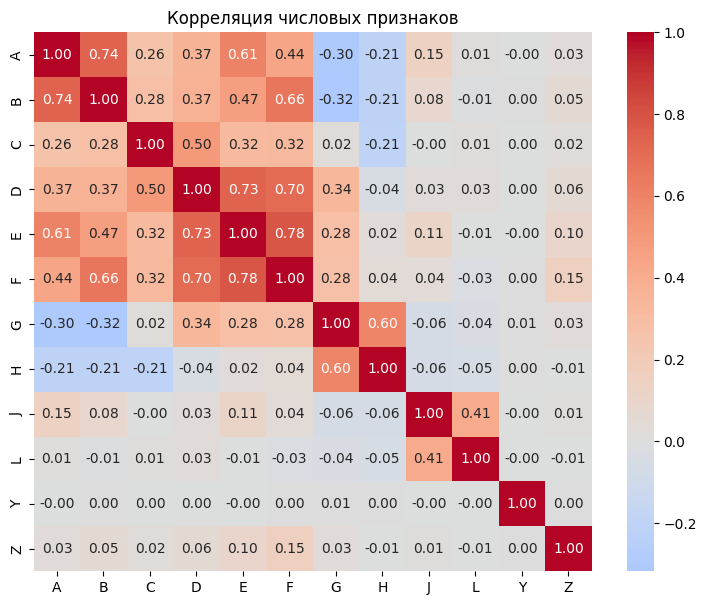

In [54]:
# изучение корреляции числовых признаков
import seaborn as sns
corr = train_data[numeric_features].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

In [55]:
# связь с таргетом
corr_target = pd.DataFrame(train_data[numeric_features + ['MARKER']].corr()['MARKER'].sort_values(ascending=False))
display(corr_target.T)

,MARKER,H,G,F,D,E,B,C,Y,Z,A,J,L
MARKER,1.0,0.07258,0.050154,0.047876,0.034378,0.029036,0.012067,0.004901,0.004847,0.000692,-0.000814,-0.022212,-0.031584


### Корреляционный анализ числовых признаков

Для числовых признаков была построена корреляционная матрица и рассчитана их линейная корреляция с целевой переменной.

Анализ показал отсутствие пар признаков с очень высокой корреляцией (|r| > 0.8), что свидетельствует об отсутствии выраженной мультиколлинеарности. Наиболее сильные взаимосвязи наблюдаются между признаками `E` и `F` (0.78), `A` и `B` (0.74), `D` и `E` (0.73), `D` и `F` (0.70), а также `G` и `H` (0.60).

При анализе связи с целевой переменной наибольшие значения корреляции были получены для признаков `H`, `G`, `F`, `D` и `E`, тогда как признаки `L` и `J` продемонстрировали слабую отрицательную связь с вероятностью дефолта.

Следует отметить, что абсолютные значения коэффициентов корреляции с целевой переменной невелики. Для задач кредитного скоринга это является ожидаемым результатом, поскольку многие зависимости между признаками и риском дефолта носят нелинейный характер.

Результаты корреляционного анализа подтверждают выводы, полученные ранее при исследовании распределений признаков, и позволяют сохранить все числовые признаки для дальнейшего моделирования.

## Итоговые выводы по EDA

В ходе разведочного анализа данных была изучена структура датасета, распределения признаков, характер пропусков, взаимосвязи между признаками и их связь с целевой переменной.

Было установлено, что задача представляет собой задачу бинарной классификации. Целевая переменная `MARKER` принимает значения 0 и 1, при этом наблюдается крайне сильный дисбаланс классов: доля дефолтных клиентов составляет около 0.38%, тогда как доля недефолтных превышает 99%. В связи с этим использование метрики Accuracy нецелесообразно, а при дальнейшем моделировании следует ориентироваться на метрики, устойчивые к дисбалансу классов.

Датасет содержит как числовые, так и категориальные признаки. При анализе категориальных переменных были обнаружены различия в написании одних и тех же значений (разный регистр и лишние пробелы), что требует предварительной очистки данных перед обучением моделей.

Исследование категориальных признаков показало наличие заметных различий в доле дефолтов между отдельными категориями. Наиболее выраженные различия наблюдаются для признаков `N`, `O`, `Q`, `R`, `S`, `W` и `X`.

Анализ числовых признаков показал, что большинство из них имеют асимметричные распределения с длинным правым хвостом. Для ряда признаков наблюдаются потенциальные выбросы и редкие экстремальные значения. Дополнительно были выявлены различия распределений между клиентами с дефолтом и без дефолта, наиболее заметные для признаков `G`, `H`, `D`, `E`, `F`, `L` и `Z`.

В ряде признаков были обнаружены пропущенные значения. Наибольшая доля пропусков наблюдается в признаках `Z` (50%), `H` (≈15%) и `L` (≈9%). Дополнительный анализ показал, что для некоторых признаков вероятность дефолта отличается для объектов с пропущенными и непропущенными значениями, что позволяет рассматривать факт отсутствия значения как потенциально полезную информацию для модели.

Корреляционный анализ числовых признаков не выявил критической мультиколлинеарности. Наиболее сильные зависимости наблюдаются между парами признаков `A-B`, `D-E`, `D-F`, `E-F` и `G-H`, однако ни одна из них не достигает уровня, требующего исключения признаков на данном этапе.

Проведенный EDA позволил получить представление о структуре данных, выявить основные особенности распределений, определить потенциально информативные признаки и сформировать стратегию дальнейшей предобработки данных.

По результатам анализа принято решение:

* привести категориальные признаки к единому формату записи;
* обработать пропущенные значения;
* рассмотреть создание индикаторов пропусков для наиболее информативных признаков;
* выполнить кодирование категориальных признаков;
* сохранить все признаки для дальнейшего моделирования;
* перейти к этапу подготовки данных и построению моделей машинного обучения.

# Очистка и разбиение

In [56]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42, stratify=y_train)
print('Train:', x_train.shape)
print('Validation:', x_val.shape)
class_dist = pd.concat([y_train.value_counts(normalize=True).rename('Train (%)'), y_val.value_counts(normalize=True).rename('Validation (%)')], axis=1)
class_dist

Train: (82375, 26)
Validation: (9153, 26)


,Train (%),Validation (%)
MARKER,,
0,0.996212,0.996176
1,0.003788,0.003824


## Разделение данных

Для оценки качества моделей обучающая выборка была дополнительно разделена на тренировочную и валидационную части.
Поскольку целевая переменная характеризуется очень сильным дисбалансом классов, использовалось стратифицированное разбиение (`stratify=y_train`). Такой подход позволяет сохранить одинаковое соотношение классов в обеих выборках. Это must have.

Размер валидационной выборки был выбран равным 10% от исходной обучающей выборке, чтобы сохранить большую часть наблюдений для обучения модели, одновременно выделив достаточное количество данных для промежуточной оценки качества.
После разбиения распределение классов практически не изменилось: доля дефолтных клиентов составила около 0.38% как в тренировочной, так и в валидационной выборке. Значит разбиение корректное.

In [57]:
# убираю лишние пробелы, и привожу к нижнему регистру
for df in [x_train, x_val, x_test]:
    df[categorical_features] = df[categorical_features].apply(lambda x: x.str.lower().str.strip())


### Очистка категориальных признаков
В ходе разведочного анализа было установлено, что часть категориальных признаков содержит одинаковые значения, записанные в различных регистрах.
Для устранения подобных несоответствий все категориальные признаки были приведены к нижнему регистру. Дополнительно были удалены лишние пробелы в начале и конце строк.
Данная процедура позволяет избежать появления искусственно различных категорий.

In [58]:
# строим препроцессор
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())])

cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
                                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_transformer, numeric_features), ('cat', cat_transformer, categorical_features)])

### Предобработка данных

#### Обработка пропущенных значений

По результатам EDA было установлено наличие пропусков как в числовых, так и в категориальных признаках.

Для числовых признаков пропуски заполнялись медианным значением. Выбор медианы обусловлен наличием асимметричных распределений и выбросов, поскольку медиана менее чувствительна к экстремальным наблюдениям по сравнению со средним значением.
Для категориальных признаков пропуски заменялись отдельной категорией `unknown`. Такой подход позволяет сохранить информацию о факте отсутствия значения и избежать искажения существующих категорий.

#### Кодирование категориальных признаков

Для преобразования категориальных признаков использовался метод One-Hot Encoding.
Данный метод создает отдельный бинарный признак для каждой категории и не предполагает наличия порядка между значениями признака.

#### Масштабирование признаков

Для числовых признаков использовался RobustScaler.

Выбор данного метода обусловлен наличием выбросов и длинных правых хвостов распределений, выявленных на этапе EDA. В отличие от StandardScaler, RobustScaler использует медиану и межквартильный размах, что делает его более устойчивым к экстремальным значениям. Другие нормализаторы (MinMaxScaler, MaxAbsScaler) даже не стоят обсуждения, они просто уничтожат данные(отнесут макс. значения к 1, а все остальные будут около 0)